In [ ]:
# Floyd-Warshall Algorithm in Python

# Number of vertices
V = 4

# Infinity representation
INF = float('inf')

# Graph represented as an adjacency matrix
# 0 means same node, INF means no direct path
graph = [
    [0,   5,  INF, 10],
    [INF, 0,   3,  INF],
    [INF, INF, 0,   1],
    [INF, INF, INF, 0]
]

def floyd_warshall(graph):
    # Copy input graph to distance matrix
    dist = [row[:] for row in graph]

    # Applying Floyd-Warshall
    for k in range(V):
        for i in range(V):
            for j in range(V):
                # If path exists through k, and is shorter, update it
                if dist[i][k] != INF and dist[k][j] != INF:
                    if dist[i][j] > dist[i][k] + dist[k][j]:
                        dist[i][j] = dist[i][k] + dist[k][j]

    return dist

# Run the algorithm
shortest_paths = floyd_warshall(graph)

# Display result
print("Shortest distances between every pair of cities:")
for row in shortest_paths:
    print(["INF" if x == INF else x for x in row])


Shortest distances between every pair of cities:
[0, 5, 8, 9]
['INF', 0, 3, 4]
['INF', 'INF', 0, 1]
['INF', 'INF', 'INF', 0]


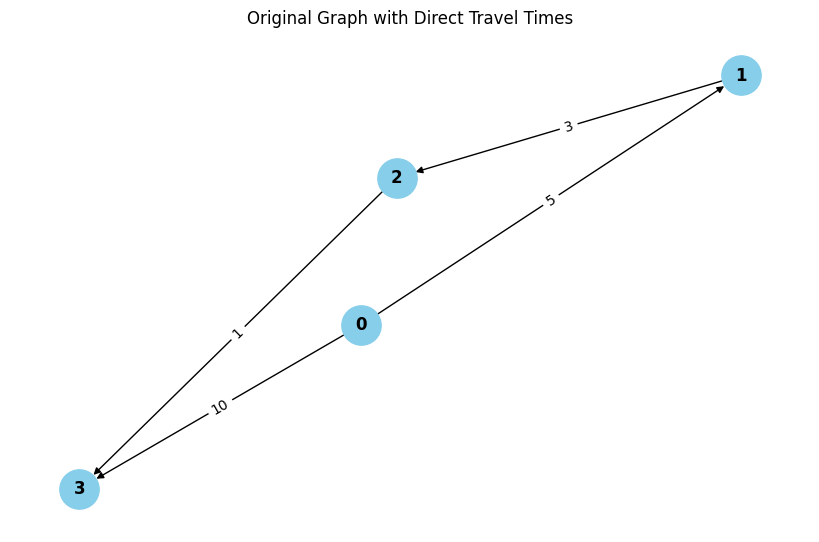

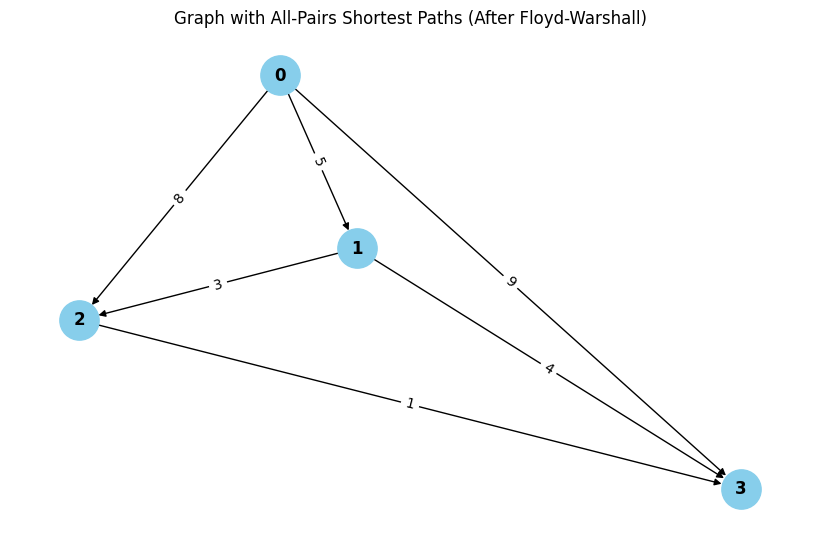

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Number of vertices
V = 4

# Infinity representation
INF = float('inf')

# Graph represented as an adjacency matrix
graph = [
    [0,   5,  INF, 10],
    [INF, 0,   3,  INF],
    [INF, INF, 0,   1],
    [INF, INF, INF, 0]
]

# Floyd-Warshall implementation
def floyd_warshall(graph):
    dist = [row[:] for row in graph]

    for k in range(V):
        for i in range(V):
            for j in range(V):
                if dist[i][k] != INF and dist[k][j] != INF:
                    if dist[i][j] > dist[i][k] + dist[k][j]:
                        dist[i][j] = dist[i][k] + dist[k][j]

    return dist

# Visualize the original graph
def visualize_graph(graph, title="Graph"):
    G = nx.DiGraph()
    for i in range(V):
        for j in range(V):
            if graph[i][j] != INF and i != j:
                G.add_edge(i, j, weight=graph[i][j])

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_size=800, node_color='skyblue', font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title(title)
    plt.show()

# Run the algorithm and visualize
shortest_paths = floyd_warshall(graph)

# Display initial and final graphs
visualize_graph(graph, title="Original Graph with Direct Travel Times")
visualize_graph(shortest_paths, title="Graph with All-Pairs Shortest Paths (After Floyd-Warshall)")
